In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)


In [ ]:
import kagglehub

path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

dataset_path = os.path.join(path, "chest_xray")  # inside the main path there is one more folder called "chest_xray"

train_path = os.path.join(dataset_path, "train") # inside chest_xray there are 2 directary "train" and "test"
test_path = os.path.join(dataset_path, "test")



In [ ]:
IMG_SIZE = (128,128)   # resizing the images into 128 * 128
BATCH_SIZE = 32        # training 5232 data dividing into 32 batches

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,                              # tensorflow goes the folder NORMAL and PNEUMONIA
    validation_split=0.2,                    # slpiting into 20 %  like it have "5000" images it 80% for traing and 20% for validation
    subset="training",                       # for load training part 80%
    seed=123,                                # Suffle the image
    image_size=IMG_SIZE,                     # Every image should be 128 * 128
    batch_size=BATCH_SIZE                    # Every Batch should be 32 * 32
)

val_ds = tf.keras.utils.image_dataset_from_directory(      # A validation dataset is a portion of the data that is not used to train the model. Instead, it is used to check how well the model is learning after each training epoch.
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.


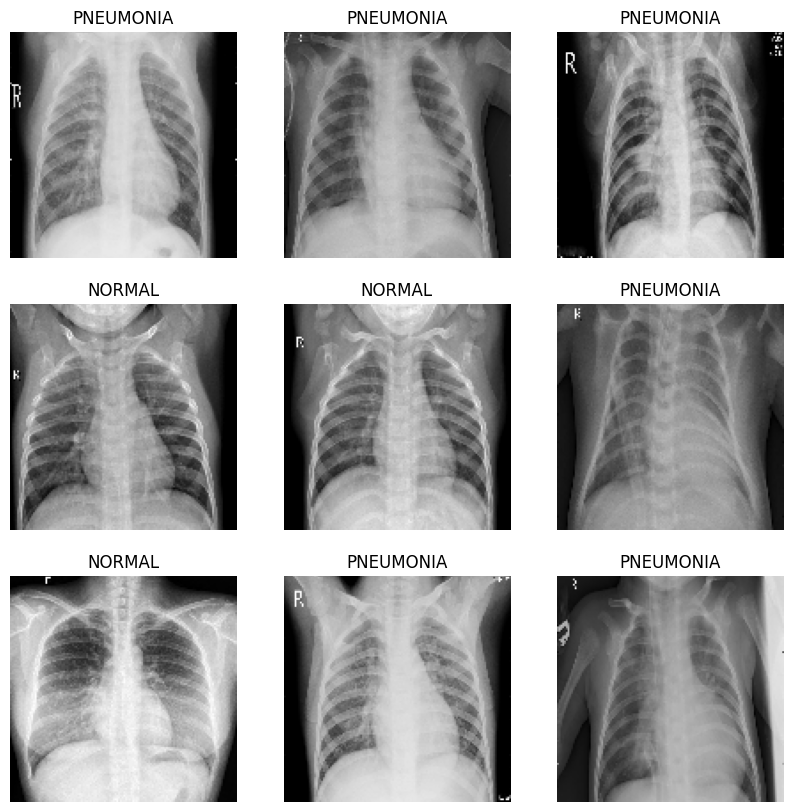

In [ ]:
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i]])

        plt.axis("off")

plt.show()

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)          # TensorFlow creates a layer that divides every pixel by 255.

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))   # train_ds contains many batches of images. train_ds contains many batches of images. x = images, y = labels
                                                                 # normalization layer is for find  "normal or pneumonia"

val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))       #
test_ds = test_ds.map(lambda x,y:(normalization_layer(x),y))

In [ ]:
model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(32, (3,3), activation='relu'))      # 32 is the filter, 3 * 3 filters look like, relu negative = 0, positve = keeps values
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())    # convert 3D dimensional to 1D dimensional vector and passed to dense

model.add(Dense(128, activation='relu'))  # Each neuron receives information from all values produced by the Flatten layer and learns to combine those extracted features to make the final decision.

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(

optimizer="adam",

loss="binary_crossentropy",

metrics=["accuracy"]

)

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(

train_ds,

validation_data=val_ds,

epochs=10

)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9429 - loss: 0.1491 - val_accuracy: 0.9646 - val_loss: 0.0970
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9539 - loss: 0.1335 - val_accuracy: 0.9560 - val_loss: 0.1085
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.9644 - loss: 0.1037 - val_accuracy: 0.9685 - val_loss: 0.0864
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9680 - loss: 0.0854 - val_accuracy: 0.9723 - val_loss: 0.0739
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9725 - loss: 0.0788 - val_accuracy: 0.9685 - val_loss: 0.0934
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9730 - loss: 0.0757 - val_accuracy: 0.9723 - val_loss: 0.0718
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9744 - loss: 0.0648 - val_accuracy: 0.9799 - val_loss: 0.0604
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9814 - loss: 0.0581 - val_accu

In [ ]:
loss,accuracy=model.evaluate(test_ds)

print("Test Loss :",loss)

print("Test Accuracy :",accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 487ms/step - accuracy: 0.8638 - loss: 0.9239
Test Loss : 0.9238756895065308
Test Accuracy : 0.8637820482254028


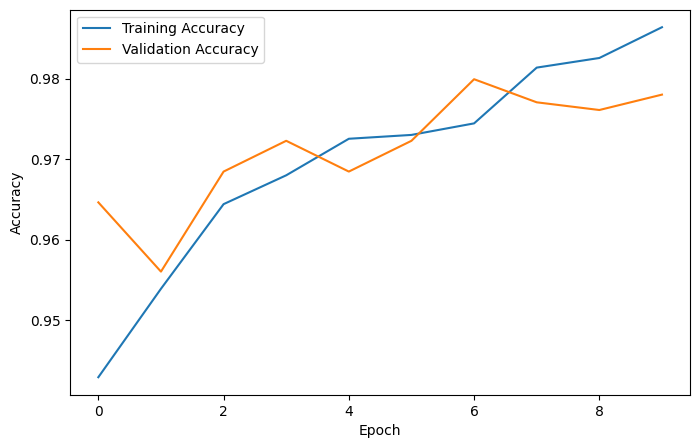

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

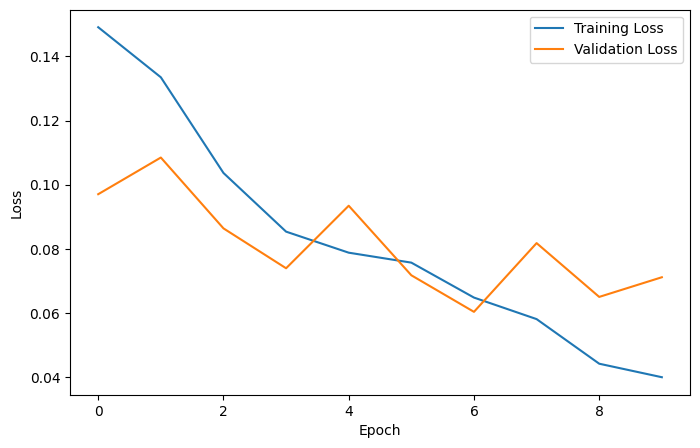

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


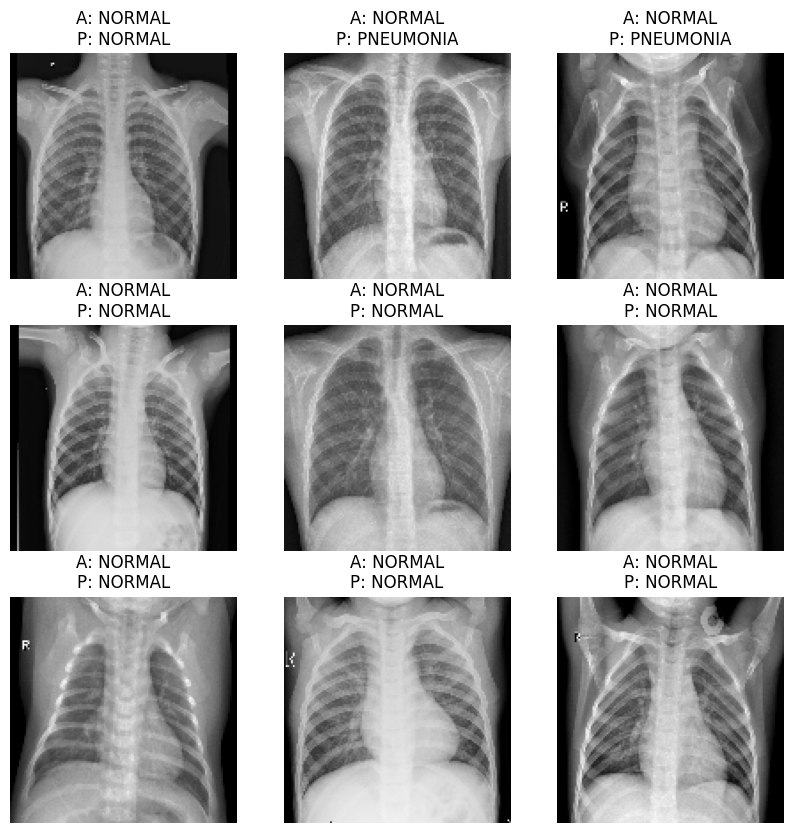

In [ ]:
import matplotlib.pyplot as plt

class_names = ['NORMAL', 'PNEUMONIA']

for images, labels in test_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(10,10))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        actual = class_names[labels[i].numpy()]
        predicted = class_names[int(predictions[i][0] > 0.5)]

        plt.title(f"A: {actual}\nP: {predicted}")
        plt.axis("off")

    plt.show()